In [13]:
from pathlib import Path
import pandas as pd

# 查找当前项目目录中的所有xlsx文件
xlsx_files = list(Path.cwd().rglob("*.xlsx"))

if not xlsx_files:
    raise FileNotFoundError("当前项目中未找到任何xlsx文件。")

# 如果有多个xlsx文件，可以选择第一个，或者根据需求做进一步选择
excel_path = xlsx_files[0]

print(f"已找到文件: {excel_path.resolve()}")
df = pd.read_excel(excel_path)
display(df.shape)
df.head()


已找到文件: D:\programming\python_script\socio-physical system for shelter\data_empirical\336170440_30000_坐标数据.xlsx


(133, 3)

,答卷序号,点选坐标,提交时间
0,1,364-192→300-226→338-192→322-496→308-148,2025-10-30 10:59:52
1,2,365-210→317-230→159-266→397-220→452-276,2025-10-30 11:01:51
2,3,258-458→357-223→591-661→320-217→506-432,2025-10-30 11:03:48
3,4,342-172→166-260→278-434→415-455→425-588→324-44...,2025-10-30 11:04:59
4,5,321-131→200-175→111-262→361-169→472-407→326-46...,2025-10-30 11:08:38


d:\anaconda\envs\CSSforthinking\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 22352 (\N{CJK UNIFIED IDEOGRAPH-5750}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda\envs\CSSforthinking\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26631 (\N{CJK UNIFIED IDEOGRAPH-6807}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda\envs\CSSforthinking\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 25152 (\N{CJK UNIFIED IDEOGRAPH-6240}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda\envs\CSSforthinking\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26377 (\N{CJK UNIFIED IDEOGRAPH-6709}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda\envs\CSSforthinking\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 31572 (\N{CJK UNIFIED IDEOGRAPH-7B5

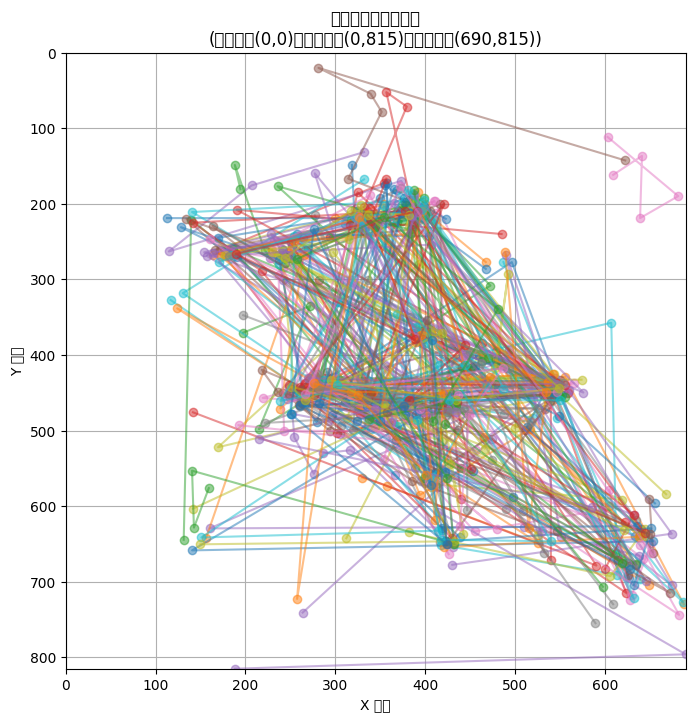

In [14]:
import matplotlib.pyplot as plt

# 假设"点选坐标"这一列存在，并且用→分隔每一对
def parse_coords(coord_str):
    points = coord_str.split('→')
    point_list = []
    for pt in points:
        try:
            x_str, y_str = pt.split('-')
            point_list.append((int(x_str), int(y_str)))
        except Exception as e:
            pass
    return point_list

# 新建一列，将字符串转为点对列表
df['点对'] = df['点选坐标'].apply(parse_coords)

# 计算原始坐标范围（用于缩放到目标坐标系）
raw_max_x, raw_max_y = 0, 0
for points in df['点对']:
    for x, y in points:
        if x > raw_max_x:
            raw_max_x = x
        if y > raw_max_y:
            raw_max_y = y

# 目标坐标系：左上(0,0)、左下(0,815)、右上(690,815)
target_width, target_height = 690, 815
x_scale = (target_width / raw_max_x) if raw_max_x else 1
y_scale = (target_height / raw_max_y) if raw_max_y else 1

# 可视化所有点对（左上角为(0,0) 的坐标系）
plt.figure(figsize=(8, 8))
for points in df['点对']:
    xs = [x * x_scale for x, _ in points]
    ys = [y * y_scale for _, y in points]
    plt.plot(xs, ys, marker='o', alpha=0.5)

plt.title('所有答卷的点选轨迹\n(左上角为(0,0)，左下角为(0,815)，右上角为(690,815))')
plt.xlabel('X 坐标')
plt.ylabel('Y 坐标')
plt.xlim(0, target_width)
plt.ylim(target_height, 0)  # 使y轴向下增大
plt.grid(True)
plt.show()





点坐标: (376.55, -192.71)
点坐标: (310.34, -226.83)
点坐标: (349.66, -192.71)
点坐标: (333.10, -497.83)
点坐标: (318.62, -148.55)
点坐标: (377.59, -210.78)
点坐标: (327.93, -230.85)
点坐标: (164.48, -266.98)
点坐标: (410.69, -220.81)
点坐标: (467.59, -277.02)
点坐标: (266.90, -459.69)
点坐标: (369.31, -223.82)
点坐标: (611.38, -663.44)
点坐标: (331.03, -217.80)
点坐标: (523.45, -433.60)
点坐标: (353.79, -172.64)
点坐标: (171.72, -260.96)
点坐标: (287.59, -435.60)
点坐标: (429.31, -456.68)
点坐标: (439.66, -590.17)
点坐标: (335.17, -450.66)
点坐标: (388.97, -370.36)
点坐标: (538.97, -439.62)
点坐标: (293.79, -243.90)
点坐标: (332.07, -131.48)
点坐标: (206.90, -175.65)
点坐标: (114.83, -262.97)
点坐标: (373.45, -169.62)
点坐标: (488.28, -408.50)
点坐标: (337.24, -464.71)
点坐标: (474.83, -510.88)
点坐标: (263.79, -740.73)
点坐标: (400.34, -569.09)
点坐标: (242.07, -449.66)
点坐标: (293.79, -499.84)
点坐标: (398.28, -212.78)
点坐标: (537.93, -433.60)
点坐标: (347.59, -228.84)
点坐标: (242.07, -285.05)
点坐标: (558.62, -448.65)
点坐标: (284.48, -452.67)
点坐标: (180.00, -261.96)
点坐标: (411.72, -211.78)
点坐标: (428.2

d:\anaconda\envs\CSSforthinking\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda\envs\CSSforthinking\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24050 (\N{CJK UNIFIED IDEOGRAPH-5DF2}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda\envs\CSSforthinking\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21453 (\N{CJK UNIFIED IDEOGRAPH-53CD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda\envs\CSSforthinking\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 36716 (\N{CJK UNIFIED IDEOGRAPH-8F6C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda\envs\CSSforthinking\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65289 (\N{FULLWIDTH RIGHT PARENTHES

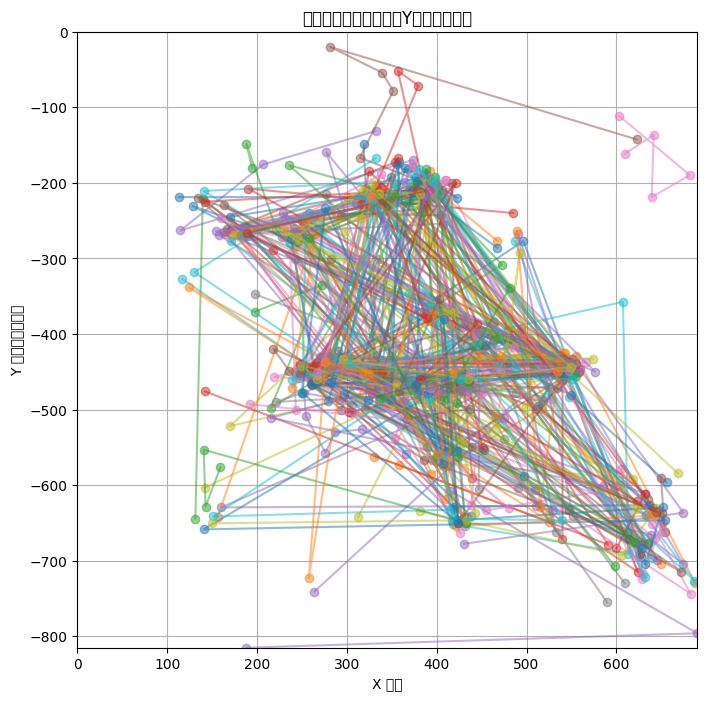

In [15]:
# 可视化所有点对的纵坐标乘以-1后的轨迹，同时输出所有坐标点
plt.figure(figsize=(8, 8))
for points in df['点对']:
    xs = [x * x_scale for x, _ in points]
    ys = [-(y * y_scale) for _, y in points]
    plt.plot(xs, ys, marker='o', alpha=0.5)
    for x_draw, y_draw in zip(xs, ys):
        print(f"点坐标: ({x_draw:.2f}, {y_draw:.2f})")
plt.title('所有答卷的点选轨迹（Y坐标反转后）')
plt.xlabel('X 坐标')
plt.ylabel('Y 坐标（已反转）')
plt.xlim(0, target_width)
plt.ylim(-target_height, 0)
plt.grid(True)
plt.show()

,答卷序号,X坐标,Y坐标(已反转)
0,1,376.551724,-192.709360
1,1,310.344828,-226.834975
2,1,349.655172,-192.709360
3,1,333.103448,-497.832512
4,1,318.620690,-148.546798
...,...,...,...
741,133,424.137931,-562.068966
742,133,257.586207,-273.004926
743,133,353.793103,-216.798030
744,133,481.034483,-339.248768


d:\anaconda\envs\CSSforthinking\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 22352 (\N{CJK UNIFIED IDEOGRAPH-5750}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda\envs\CSSforthinking\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26631 (\N{CJK UNIFIED IDEOGRAPH-6807}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda\envs\CSSforthinking\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24050 (\N{CJK UNIFIED IDEOGRAPH-5DF2}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda\envs\CSSforthinking\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21453 (\N{CJK UNIFIED IDEOGRAPH-53CD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda\envs\CSSforthinking\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 36716 (\N{CJK UNIFIED IDEOGRAPH-8F6

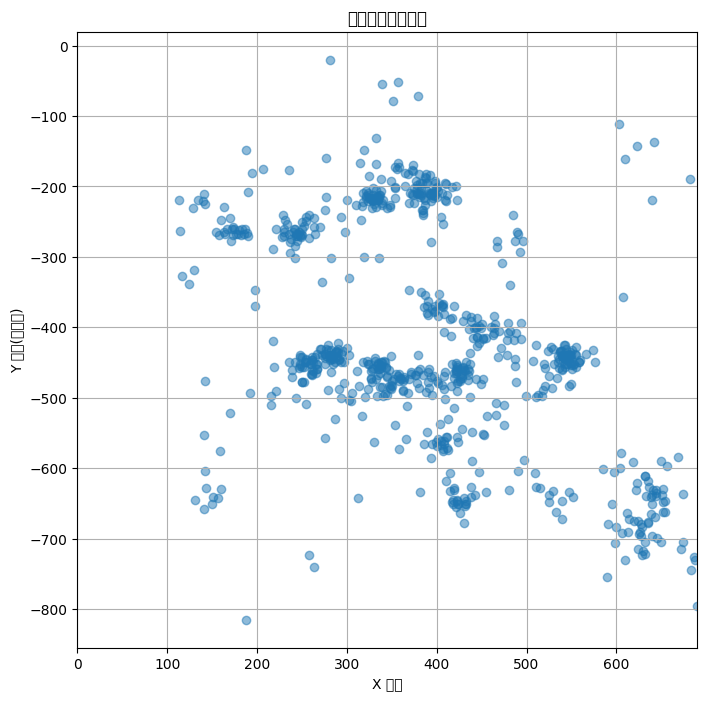

In [16]:

# 输出所有点的坐标组成的DataFrame
all_points = []
for idx, points in enumerate(df['点对']):
    for x, y in points:
        # 这里使用缩放后的坐标，更直观
        scaled_x = x * x_scale
        scaled_y = -(y * y_scale)
        all_points.append({
            '答卷序号': df.iloc[idx]['答卷序号'] if '答卷序号' in df.columns else idx + 1,
            'X坐标': scaled_x,
            'Y坐标(已反转)': scaled_y
        })

points_df = pd.DataFrame(all_points)
display(points_df)

plt.figure(figsize=(8, 8))
plt.scatter(points_df['X坐标'], points_df['Y坐标(已反转)'], alpha=0.5)
plt.title('所有答卷点的分布')
plt.xlabel('X 坐标')
plt.ylabel('Y 坐标(已反转)')
plt.xlim(0, 690)
plt.grid(True)
plt.show()


,答卷序号,X坐标,Y坐标(已反转)
0,1,376.551724,622.290640
1,1,310.344828,588.165025
2,1,349.655172,622.290640
3,1,333.103448,317.167488
4,1,318.620690,666.453202
...,...,...,...
741,133,424.137931,252.931034
742,133,257.586207,541.995074
743,133,353.793103,598.201970
744,133,481.034483,475.751232


d:\anaconda\envs\CSSforthinking\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 22352 (\N{CJK UNIFIED IDEOGRAPH-5750}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda\envs\CSSforthinking\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26631 (\N{CJK UNIFIED IDEOGRAPH-6807}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda\envs\CSSforthinking\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda\envs\CSSforthinking\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 36793 (\N{CJK UNIFIED IDEOGRAPH-8FB9}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda\envs\CSSforthinking\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 30028 (\N{CJK UNIFIED IDEOGRAPH-754

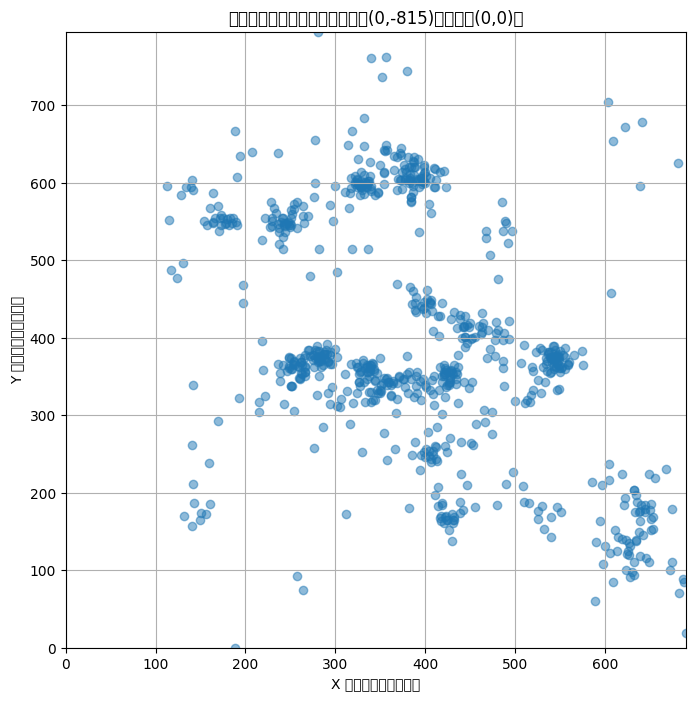

In [17]:
# 不再是将左下角实际点变为(0,0)，
# 而是将左下边界(0, -815)映射为(0, 0)，其他点相应变化（即 y_new = y_old + 815 ）
# X坐标不需调整，Y坐标整体加815

points_df_moved = points_df.copy()
points_df_moved['X坐标'] = points_df_moved['X坐标']
points_df_moved['Y坐标(已反转)'] = points_df_moved['Y坐标(已反转)'] + 815

display(points_df_moved)

plt.figure(figsize=(8,8))
plt.scatter(points_df_moved['X坐标'], points_df_moved['Y坐标(已反转)'], alpha=0.5)
plt.title('所有答卷点的分布（左下角边界(0,-815)已对齐为(0,0)）')
plt.xlabel('X 坐标（边界平移后）')
plt.ylabel('Y 坐标（边界平移后）')
plt.xlim(0, points_df_moved['X坐标'].max())
plt.ylim(0, points_df_moved['Y坐标(已反转)'].max())
plt.grid(True)
plt.show()


d:\anaconda\envs\CSSforthinking\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21472 (\N{CJK UNIFIED IDEOGRAPH-53E0}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda\envs\CSSforthinking\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21152 (\N{CJK UNIFIED IDEOGRAPH-52A0}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


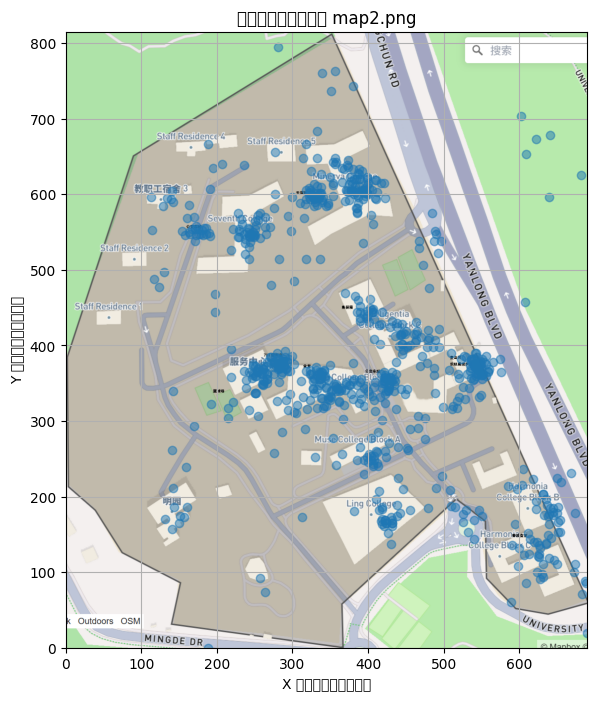

In [18]:
import matplotlib.image as mpimg

# 叠加map2.png作为背景
img = mpimg.imread('map2.png')

fig, ax = plt.subplots(figsize=(8,8))
# 直接按照图片坐标显示，不再设置origin='lower'
ax.imshow(img, extent=[0, 690, 0, 815])  # 默认origin='upper'，和图片坐标一致
ax.scatter(points_df_moved['X坐标'], points_df_moved['Y坐标(已反转)'], alpha=0.5)
ax.set_title('所有答卷点分布叠加 map2.png')
ax.set_xlabel('X 坐标（边界平移后）')
ax.set_ylabel('Y 坐标（边界平移后）')
ax.set_xlim(0, 690)
ax.set_ylim(0, 815)
ax.grid(True)
plt.show()


In [19]:
import matplotlib.pyplot as plt

In [20]:
import json

# 读取geojson的polygon边界
with open('boan.geojson', encoding='utf-8') as f:
    gj = json.load(f)

polygon_coords = gj['features'][0]['geometry']['coordinates'][0]
polygon_coords


[[274.8238772471668, 636.6110108552966],
 [68.55423053004779, 509.9618258611299],
 [0.0, 301.14927557716146],
 [1.330201282806229, 166.63535179710016],
 [29.350446722412016, 142.31745650421362],
 [57.394868236151524, 98.28596834593918],
 [118.07963970582932, 67.05030827375595],
 [108.80198009684682, 24.132630401989445],
 [287.2732299035415, 0.0],
 [286.0510435543838, 45.22412030631676],
 [404.8761259599705, 154.37629049178213],
 [435.22809623280773, 131.22159224026836],
 [436.46801607875386, 72.08220651524607],
 [466.8303065394284, 40.810054092668],
 [500.6596932657412, 35.05412503425032],
 [542.6313022772665, 46.702911492902786],
 [274.8238772471668, 636.6110108552966]]

d:\anaconda\envs\CSSforthinking\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21487 (\N{CJK UNIFIED IDEOGRAPH-53EF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda\envs\CSSforthinking\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 35270 (\N{CJK UNIFIED IDEOGRAPH-89C6}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda\envs\CSSforthinking\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21270 (\N{CJK UNIFIED IDEOGRAPH-5316}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


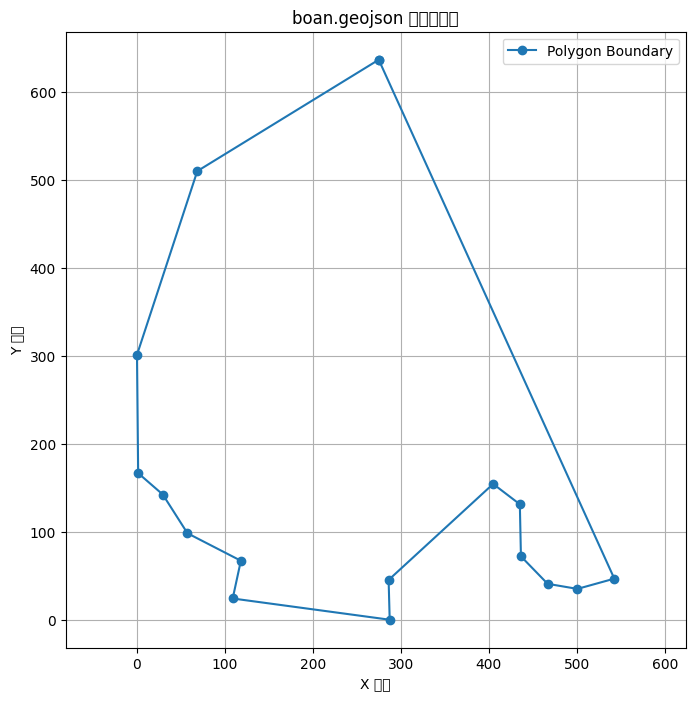

In [21]:
# 可视化 polygon_coords
import matplotlib.pyplot as plt

# 提取X和Y坐标
polygon_x = [pt[0] for pt in polygon_coords]
polygon_y = [pt[1] for pt in polygon_coords]

plt.figure(figsize=(8,8))
plt.plot(polygon_x, polygon_y, '-o', label='Polygon Boundary')
plt.title('boan.geojson 边界可视化')
plt.xlabel('X 坐标')
plt.ylabel('Y 坐标')
plt.axis('equal')
plt.grid(True)
plt.legend()
plt.show()


In [22]:
# 输出 polygon 的外框四个点（左下，左上，右上，右下）
import numpy as np

polygon_array = np.array(polygon_coords)
min_x = np.min(polygon_array[:,0])
max_x = np.max(polygon_array[:,0])
min_y = np.min(polygon_array[:,1])
max_y = np.max(polygon_array[:,1])

corner_points = [
    (min_x, min_y),  # 左下
    (min_x, max_y),  # 左上
    (max_x, max_y),  # 右上
    (max_x, min_y),  # 右下
]

print("Polygon 外框四个点为（左下、左上、右上、右下）：")
for i, pt in enumerate(corner_points, 1):
    print(f"{i}: {pt}")



Polygon 外框四个点为（左下、左上、右上、右下）：
1: (np.float64(0.0), np.float64(0.0))
2: (np.float64(0.0), np.float64(636.6110108552966))
3: (np.float64(542.6313022772665), np.float64(636.6110108552966))
4: (np.float64(542.6313022772665), np.float64(0.0))


d:\anaconda\envs\CSSforthinking\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21450 (\N{CJK UNIFIED IDEOGRAPH-53CA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda\envs\CSSforthinking\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 22806 (\N{CJK UNIFIED IDEOGRAPH-5916}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda\envs\CSSforthinking\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26694 (\N{CJK UNIFIED IDEOGRAPH-6846}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda\envs\CSSforthinking\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 22235 (\N{CJK UNIFIED IDEOGRAPH-56DB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda\envs\CSSforthinking\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20010 (\N{CJK UNIFIED IDEOGRAPH-4E2

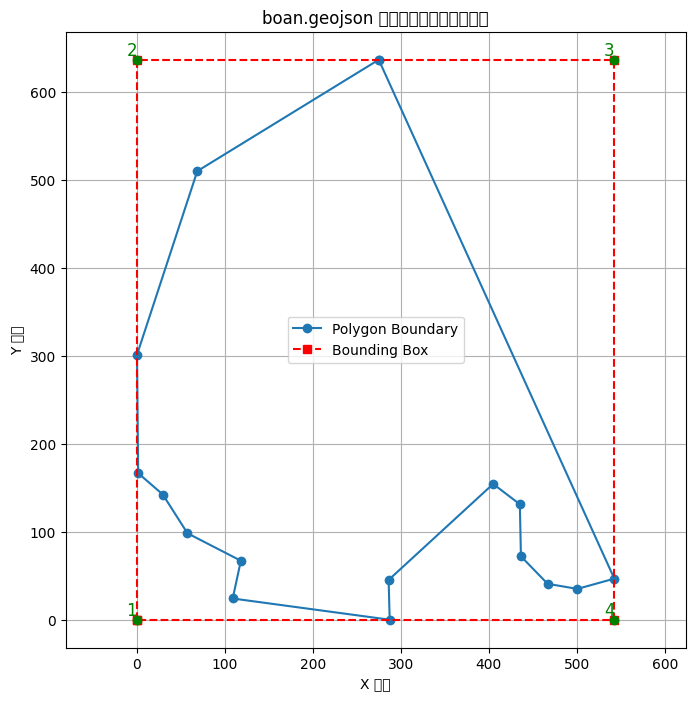

In [23]:
plt.figure(figsize=(8,8))

# 绘制polygon边界
plt.plot(polygon_x, polygon_y, '-o', label='Polygon Boundary')

# 绘制外框四个点连成的矩形
corner_x = [pt[0] for pt in corner_points] + [corner_points[0][0]]
corner_y = [pt[1] for pt in corner_points] + [corner_points[0][1]]
plt.plot(corner_x, corner_y, '--s', color='red', label='Bounding Box')

# 标记四个角点
for idx, pt in enumerate(corner_points, 1):
    plt.scatter(pt[0], pt[1], color='green', zorder=5)
    plt.text(pt[0], pt[1], f'{idx}', fontsize=12, color='green', verticalalignment='bottom', horizontalalignment='right')

plt.title('boan.geojson 边界及外框四个点可视化')
plt.xlabel('X 坐标')
plt.ylabel('Y 坐标')
plt.axis('equal')
plt.grid(True)
plt.legend()
plt.show()


In [24]:
points_df_moved

,答卷序号,X坐标,Y坐标(已反转)
0,1,376.551724,622.290640
1,1,310.344828,588.165025
2,1,349.655172,622.290640
3,1,333.103448,317.167488
4,1,318.620690,666.453202
...,...,...,...
741,133,424.137931,252.931034
742,133,257.586207,541.995074
743,133,353.793103,598.201970
744,133,481.034483,475.751232


In [30]:
# 将points_df_moved中的点按原边框映射到boan.geojson外框对应的边框
# 假设points_df_moved存在，其包含"X坐标"、"Y坐标(已反转)"两列
# 原边框坐标（之前的坐标体系）
orig_min_x = 0
orig_max_x = 690
orig_min_y = 0
orig_max_y = 815

# 目标边框坐标，即boan.geojson外框
target_min_x, target_min_y = min_x, min_y
target_max_x, target_max_y = max_x, max_y

# 线性缩放映射函数
def map_point(x, y):
    # 防止零除和边界重叠问题
    if orig_max_x == orig_min_x:
        tx = target_min_x
    else:
        tx = (x - orig_min_x) / (orig_max_x - orig_min_x) * (target_max_x - target_min_x) + target_min_x
    if orig_max_y == orig_min_y:
        ty = target_min_y
    else:
        ty = (y - orig_min_y) / (orig_max_y - orig_min_y) * (target_max_y - target_min_y) + target_min_y
    return tx, ty

# 应用到所有点
mapped_points = points_df_moved.apply(lambda row: map_point(row['X坐标'], row['Y坐标(已反转)']), axis=1)
points_df_moved[['映射后_X坐标', '映射后_Y坐标']] = pd.DataFrame(mapped_points.tolist(), index=points_df_moved.index)

# 输出point_final
point_final = points_df_moved.copy()
# 你可以选取你需要的列，如下面只保留答卷序号和映射后的坐标
point_final = point_final[['答卷序号', '映射后_X坐标', '映射后_Y坐标']]




In [ ]:
point_final

In [31]:
orig_min_x

0

d:\anaconda\envs\CSSforthinking\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26144 (\N{CJK UNIFIED IDEOGRAPH-6620}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda\envs\CSSforthinking\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 23556 (\N{CJK UNIFIED IDEOGRAPH-5C04}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda\envs\CSSforthinking\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21518 (\N{CJK UNIFIED IDEOGRAPH-540E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda\envs\CSSforthinking\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 22352 (\N{CJK UNIFIED IDEOGRAPH-5750}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda\envs\CSSforthinking\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26631 (\N{CJK UNIFIED IDEOGRAPH-680

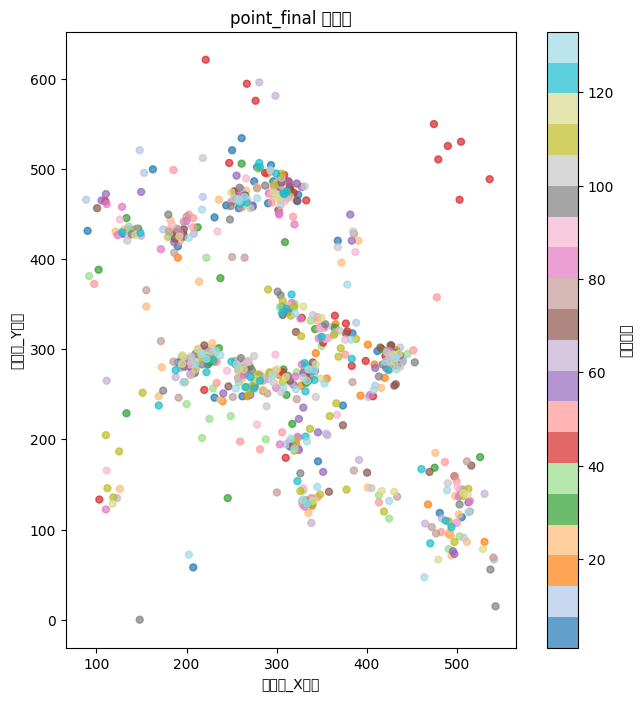

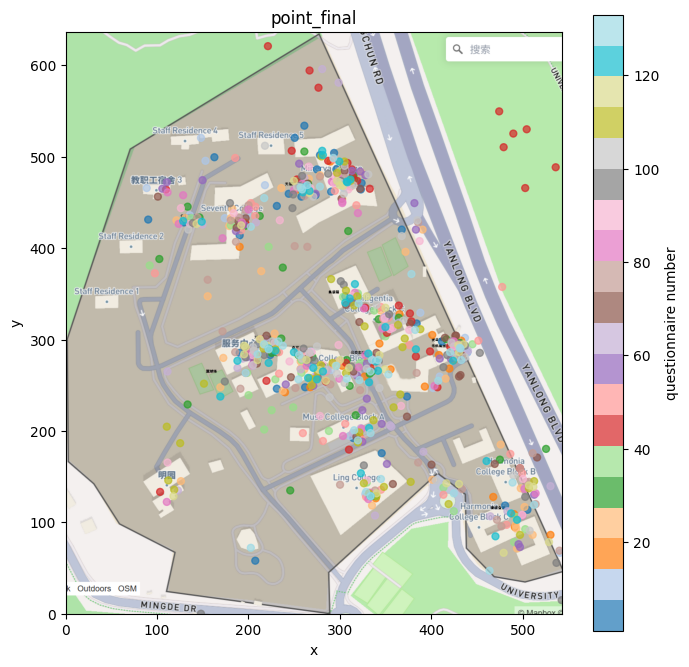

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
# 绘制所有答卷的点，按答卷序号上色
scatter = plt.scatter(point_final['映射后_X坐标'], point_final['映射后_Y坐标'],
                     c=point_final['答卷序号'], cmap='tab20', s=25, alpha=0.7)
plt.xlabel('映射后_X坐标')
plt.ylabel('映射后_Y坐标')
plt.title('point_final 可视化')
plt.colorbar(scatter, label='答卷序号')
plt.gca().set_aspect('equal')
plt.show()
# 在散点图下方叠加map2.png底图

import matplotlib.image as mpimg

# 读取底图
img = mpimg.imread('map2.png')

# 获取底图的显示范围（与target_min/max对应）
extent = [target_min_x, target_max_x, target_min_y, target_max_y]

plt.figure(figsize=(8, 8))
plt.imshow(img, extent=extent, origin='upper')  # origin='upper'确保图片方向与映射一致

# 绘制所有答卷的点，按答卷序号上色
scatter = plt.scatter(point_final['映射后_X坐标'], point_final['映射后_Y坐标'],
                     c=point_final['答卷序号'], cmap='tab20', s=25, alpha=0.7)

plt.xlabel('x')
plt.ylabel('y')
plt.title('point_final')
plt.colorbar(scatter, label='questionnaire number')
plt.gca().set_aspect('equal')
plt.show()


我需要进行有效的数据筛选。

我现在在思考如何处理一些明显不合理的数据。把数据给剔除了

是要聚合一些点的数据吗？

In [6]:
# 必要库
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1) 读取数据（如果你 notebook 里已有 point_final 变量，可跳过CSV读取，直接用它）
csv_path = 'point_final.csv'  # 或者直接用已有的 point_final DataFrame
df = pd.read_csv(csv_path, encoding='utf-8-sig')  # 列: ['答卷序号','映射后_X坐标','映射后_Y坐标']

# 2) 读取边界 polygon（boan.geojson）
with open('boan.geojson', encoding='utf-8') as f:
    gj = json.load(f)
polygon_coords = gj['features'][0]['geometry']['coordinates'][0]  # 外环

# 3) 基于边界筛点（含边界上的点）
# 优先用 shapely；如未安装则回退到 matplotlib.path
try:
    from shapely.geometry import Point, Polygon
    poly = Polygon(polygon_coords).buffer(0)  # buffer(0) 修复可能的自交/方向问题
    mask = [poly.covers(Point(x, y)) for x, y in zip(df['映射后_X坐标'], df['映射后_Y坐标'])]
except Exception:
    from matplotlib.path import Path
    poly_path = Path(polygon_coords)
    pts = np.column_stack([df['映射后_X坐标'].to_numpy(), df['映射后_Y坐标'].to_numpy()])
    # radius 轻微负值，尽量将边界点纳入
    mask = poly_path.contains_points(pts, radius=-1e-9)

df_in = df.loc[mask].reset_index(drop=True)

# 4) 为“同一答卷内，越靠前的点击权重越大”生成样本权重
# 使用文件出现顺序作为每份答卷的点击顺序；你若有更准确的点击时间戳，可替换这里的顺序依据
decay = 0.8  # 衰减系数（0.6~0.9常用，越小越强调前几次点击）
df_in['_seq'] = df_in.groupby('答卷序号').cumcount() + 1
df_in['sample_weight'] = decay ** (df_in['_seq'] - 1)

# 5) 聚类方案A（默认且无需装额外库）：GaussianMixture + BIC自动选簇数（加权）
from sklearn.mixture import GaussianMixture

X = df_in[['映射后_X坐标', '映射后_Y坐标']].to_numpy()
w = df_in['sample_weight'].to_numpy()

# 为了“尽量少”，只在较小k范围内搜索；可按需调大
candidate_ks = list(range(2, min(9, max(3, len(df_in)//80 + 3))))  # 2~8(或随样本数略放宽)
models, bics = [], []
for k in candidate_ks:
    gm = GaussianMixture(n_components=k, covariance_type='full', random_state=42)
    gm.fit(X, sample_weight=w)
    bics.append(gm.bic(X))  # BIC基于当前模型评估
    models.append(gm)

best_idx = int(np.argmin(bics))
best_k = candidate_ks[best_idx]
best_model = models[best_idx]
labels = best_model.predict(X)
centers = best_model.means_

df_in['cluster'] = labels

print(f'[GMM] 选定簇数: {best_k}, BIC: {bics[best_idx]:.2f}')
print(df_in.groupby('cluster').size().rename('count').to_frame())
print('\n各簇中心(映射坐标系):')
print(pd.DataFrame(centers, columns=['cx','cy']).assign(cluster=range(best_k)))

# 6) 可选：聚类方案B（HDBSCAN，自带噪声识别&自动簇数，若已安装可尝试）
# import hdbscan
# clusterer = hdbscan.HDBSCAN(min_cluster_size=10, min_samples=5, cluster_selection_epsilon=3)
# clusterer.fit(X, sample_weight=w)
# labels_hdb = clusterer.labels_
# df_in['cluster_hdb'] = labels_hdb
# print('HDBSCAN 簇数(不含噪声-1):', len(set(labels_hdb) - {-1}))

# 7) 保存结果
out_csv = 'point_clustered.csv'
df_in[['答卷序号','映射后_X坐标','映射后_Y坐标','sample_weight','cluster']].to_csv(out_csv, index=False, encoding='utf-8-sig')
print(f'已保存聚类结果到: {out_csv}')

# 8) 可视化（边界 + 聚类结果）
plt.figure(figsize=(8,8))
px, py = zip(*polygon_coords)
plt.plot(px, py, '-k', lw=1.2, label='boundary')

sc = plt.scatter(df_in['映射后_X坐标'], df_in['映射后_Y坐标'],
                 c=df_in['cluster'], cmap='tab10', s=14, alpha=0.8)
plt.colorbar(sc, label='cluster')

# 画GMM中心
plt.scatter(centers[:,0], centers[:,1], c='red', s=80, marker='X', label='centroid')

plt.gca().set_aspect('equal')
plt.title(f'Filtered in-boundary points + GMM clustering (k={best_k})')
plt.legend()
plt.show()

TypeError: BaseMixture.fit() got an unexpected keyword argument 'sample_weight'

[GMM] 模式: expanded, 选定簇数: 28, BIC: 48363.07
         count
cluster       
0           21
1           41
2           29
3           11
4           30
5            7
6           49
7           38
8           18
9           11
10          39
11          24
12          18
13          20
14          45
15          41
16          61
17          30
18          13
19           4
20           5
21          25
22           9
23           6
24          30
25          36
26           2
27          17

各簇中心(映射坐标系):
            cx          cy  cluster
0   334.193221  131.365054        0
1   259.112858  465.763632        1
2   337.240795  274.285823        2
3   208.725781  248.601399        3
4   489.934166   93.317648        4
5   106.115731  463.742650        5
6   266.787386  271.780438        6
7   426.259551  288.974996        7
8   277.977147  494.756549        8
9   118.525429  163.375524        9
10  191.759449  430.031433       10
11  315.521379  343.645862       11
12  223.827288  245.9434

d:\anaconda\envs\CSSforthinking\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda\envs\CSSforthinking\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 38543 (\N{CJK UNIFIED IDEOGRAPH-968F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda\envs\CSSforthinking\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 31751 (\N{CJK UNIFIED IDEOGRAPH-7C07}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda\envs\CSSforthinking\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda\envs\CSSforthinking\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21464 (\N{CJK UNIFIED IDEOGRAPH-53D

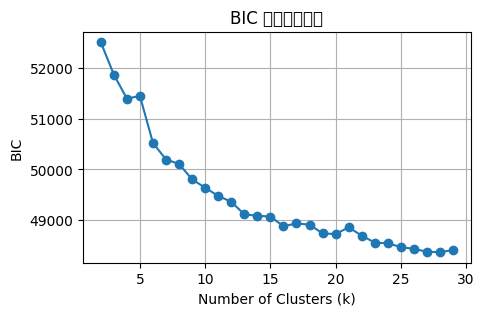

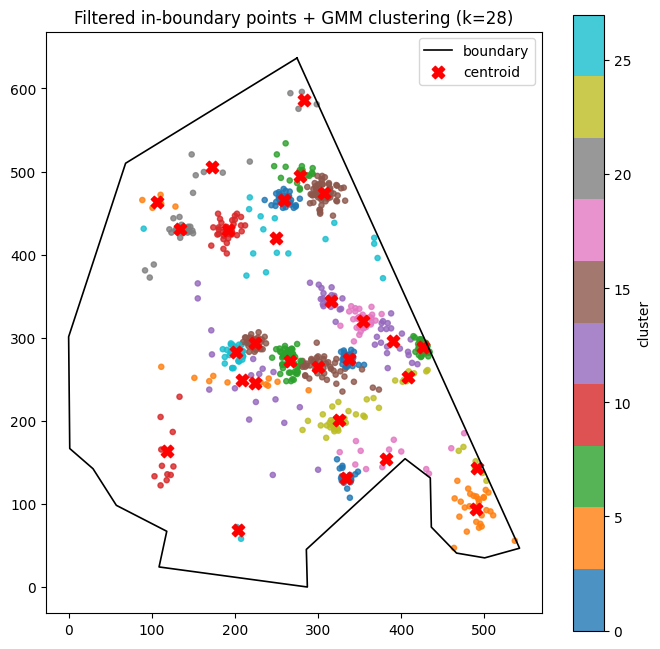

In [9]:
# 5) 聚类方案A（兼容旧版sklearn）：GaussianMixture + BIC 自动选簇数（带权重/扩样回退）
from sklearn.mixture import GaussianMixture
import inspect
import matplotlib.pyplot as plt

X = df_in[['映射后_X坐标', '映射后_Y坐标']].to_numpy()
w = df_in['sample_weight'].to_numpy()

# 为了“尽量少簇”，可适当收紧搜索范围
candidate_ks = list(range(2, 30)  )# 2~8

def fit_gmm_auto(X, w, candidate_ks, random_state=42):
    # 判断是否原生支持 sample_weight
    try:
        supports_weight = ('sample_weight' in inspect.signature(GaussianMixture.fit).parameters)
    except Exception:
        supports_weight = False

    models, bics = [], []
    mode = 'native' if supports_weight else 'expanded'

    if supports_weight:
        for k in candidate_ks:
            gm = GaussianMixture(n_components=k, covariance_type='full', random_state=random_state)
            gm.fit(X, sample_weight=w)
            bics.append(gm.bic(X))
            models.append(gm)
    else:
        # 回退：按权重扩样（避免数据量爆炸，映射到1~5次）
        w_norm = w / w.max() if w.max() > 0 else w
        reps = np.clip(np.round(5 * w_norm), 1, 5).astype(int)  # 想更强调权重，可把5调大
        X_rep = np.repeat(X, reps, axis=0)
        for k in candidate_ks:
            gm = GaussianMixture(n_components=k, covariance_type='full', random_state=random_state)
            gm.fit(X_rep)
            bics.append(gm.bic(X_rep))
            models.append(gm)

    best_idx = int(np.argmin(bics))
    best_k = candidate_ks[best_idx]
    best_model = models[best_idx]
    labels = best_model.predict(X)         # 在原始样本上出预测
    centers = best_model.means_
    return best_k, best_model, labels, centers, bics[best_idx], mode, bics, models

best_k, best_model, labels, centers, best_bic, mode, bics, models = fit_gmm_auto(X, w, candidate_ks)
df_in['cluster'] = labels

print(f'[GMM] 模式: {mode}, 选定簇数: {best_k}, BIC: {best_bic:.2f}')
print(df_in.groupby('cluster').size().rename('count').to_frame())
print('\n各簇中心(映射坐标系):')
print(pd.DataFrame(centers, columns=['cx','cy']).assign(cluster=range(best_k)))

# ---- 可视化部分 ----
# 可视化不同k下的BIC
plt.figure(figsize=(5, 3))
plt.plot(candidate_ks, bics, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("BIC")
plt.title("BIC 值随簇数变化")
plt.grid(True)
plt.show()

# 可视化聚类结果
plt.figure(figsize=(8,8))
# 建议提前准备 polygon_coords 边界（如：polygon_coords = [[...], ...]）
try:
    px, py = zip(*polygon_coords)
    plt.plot(px, py, '-k', lw=1.2, label='boundary')
except Exception:
    pass

sc = plt.scatter(df_in['映射后_X坐标'], df_in['映射后_Y坐标'],
                 c=df_in['cluster'], cmap='tab10', s=14, alpha=0.8)
plt.colorbar(sc, label='cluster')

# 画GMM中心
plt.scatter(centers[:,0], centers[:,1], c='red', s=80, marker='X', label='centroid')

plt.gca().set_aspect('equal')
plt.title(f'Filtered in-boundary points + GMM clustering (k={best_k})')
plt.legend()
plt.show()

In [10]:
import json

# 构造GeoJSON结构
geojson_centers = {
    "type": "FeatureCollection",
    "features": [
        {
            "type": "Feature",
            "properties": {"cluster": int(i)},
            "geometry": {
                "type": "Point",
                "coordinates": [float(cx), float(cy)]
            }
        }
        for i, (cx, cy) in enumerate(centers)
    ]
}

# 输出为geojson文件
with open("gmm_centers.geojson", "w", encoding="utf-8") as f:
    json.dump(geojson_centers, f, ensure_ascii=False, indent=2)

print("已导出GMM聚类中心点为 geojson 文件: gmm_centers.geojson")

已导出GMM聚类中心点为 geojson 文件: gmm_centers.geojson


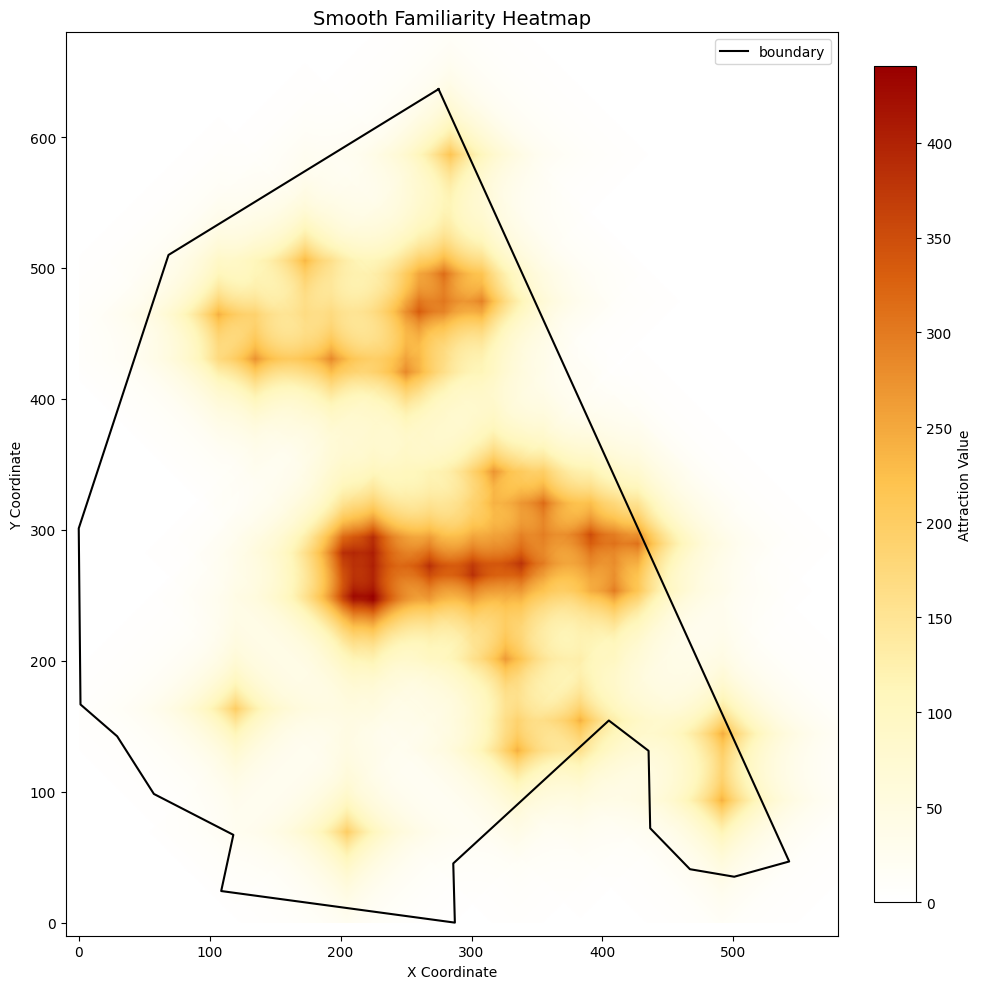

In [33]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import os

def plot_attraction_heatmap_smooth(json_path, boundary_path, grid_size=(700, 700)):
    """
    实现无缝融合的热力图：
    1. 自定义从白色开始的色带
    2. 使用双线性插值消除锯齿
    """
    if not os.path.exists(json_path):
        print(f"文件不存在: {json_path}")
        return

    # 1. 加载数据
    with open(json_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    flat_map = data.get("macro_environment", {}).get("map", [])
    matrix = np.array(flat_map).reshape(grid_size)
    matrix_plot = matrix.T.astype(float) # 保持原始数值，不设为 NaN

    # 2. 【核心优化】创建自定义色带：从纯白 (#ffffff) 平滑过渡到热力色
    # 我们参考 YlOrRd 的配色，但把起点强制改为白色
    colors = ["#ffffff", "#fff7bc", "#fec44f", "#d95f0e", "#990000"]
    custom_cmap = mcolors.LinearSegmentedColormap.from_list("smooth_heat", colors, N=256)

    # 3. 绘图配置
    plt.figure(figsize=(10, 10), facecolor='white')
    ax = plt.gca()

    # 4. 【关键参数】使用 interpolation='bilinear' 让边缘平滑模糊
    # vmin=0 确保 0 值准确对应色带开头的白色
    img = ax.imshow(
        matrix_plot, 
        extent=[0, grid_size[0], 0, grid_size[1]], 
        origin='lower', 
        cmap=custom_cmap, 
        vmin=0,           # 强制从 0 开始渲染，使 0 值变为白色
        aspect='equal',
        interpolation='bilinear', # 开启双线性插值，消除锯齿
        alpha=1.0
    )

    # 5. 叠加边界 (加粗黑色线，更醒目)
    if os.path.exists(boundary_path):
        with open(boundary_path, 'r', encoding='utf-8') as f:
            boundary_data = json.load(f)
            feature = boundary_data['features'][0]
            boundary_coords = np.array(feature['geometry']['coordinates'][0])
            plt.plot(boundary_coords[:, 0], boundary_coords[:, 1], 
                     color='black', linewidth=1.5, label='boundary', zorder=3)

    # 6. 对齐坐标范围
    plt.xlim(-10, 580)
    plt.ylim(-10, 680)

    # 7. 细节打磨
    plt.title("Smooth Familiarity Heatmap", fontsize=14)
    plt.xlabel("X Coordinate")
    plt.ylabel("Y Coordinate")
    plt.legend(loc='upper right')
    
    # 调整 colorbar
    cbar = plt.colorbar(img, fraction=0.046, pad=0.04)
    cbar.set_label('Attraction Value')

    plt.grid(False)
    plt.tight_layout()
    plt.show()

# --- 执行 ---
base_path = r"D:\progamming\python_script\Social-physical-system-shelter"
target_file = os.path.join(base_path, "data", "env_data", "attraction_matrix_familiar_points.json")
boundary_file = os.path.join(base_path, "data_empirical", "boan.geojson")

plot_attraction_heatmap_smooth(target_file, boundary_file)

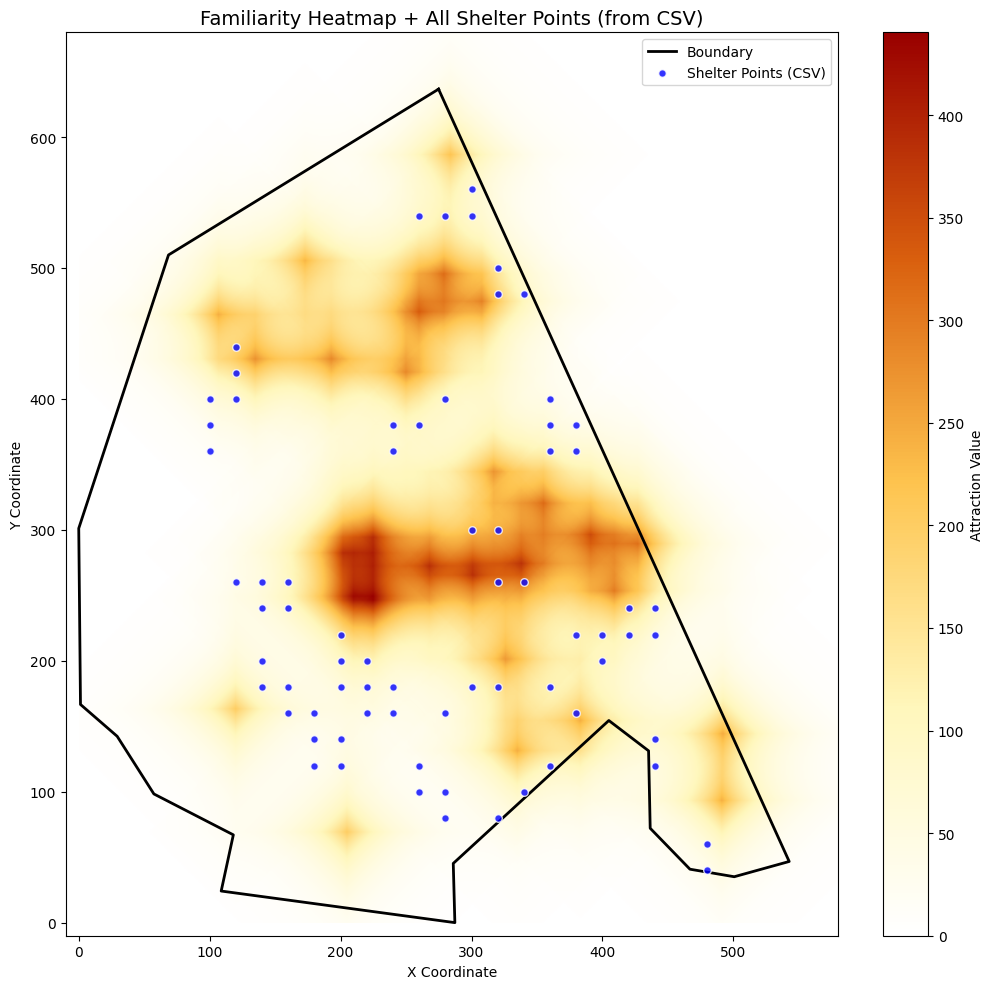

In [34]:
import pandas as pd
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import os

def plot_heatmap_with_shelter_csv(json_path, boundary_path, csv_path, grid_size=(700, 700)):
    # 1. 加载熟悉度热力图数据
    with open(json_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    flat_map = data.get("macro_environment", {}).get("map", [])
    matrix = np.array(flat_map).reshape(grid_size)
    matrix_plot = matrix.T.astype(float)

    # 2. 加载 CSV 坐标点
    shelter_df = pd.read_csv(csv_path)

    # 3. 创建自定义色带
    colors = ["#ffffff", "#fff7bc", "#fec44f", "#d95f0e", "#990000"]
    custom_cmap = mcolors.LinearSegmentedColormap.from_list("smooth_heat", colors, N=256)

    # 4. 绘图
    plt.figure(figsize=(12, 10), facecolor='white')
    ax = plt.gca()

    # 绘制热力图底图
    img = ax.imshow(
        matrix_plot, 
        extent=[0, grid_size[0], 0, grid_size[1]], 
        origin='lower', 
        cmap=custom_cmap, 
        vmin=0,           
        aspect='equal',
        interpolation='bilinear', 
        alpha=1.0,
        zorder=1
    )

    # 5. 叠加边界线
    if os.path.exists(boundary_path):
        with open(boundary_path, 'r', encoding='utf-8') as f:
            boundary_data = json.load(f)
            feature = boundary_data['features'][0]
            boundary_coords = np.array(feature['geometry']['coordinates'][0])
            plt.plot(boundary_coords[:, 0], boundary_coords[:, 1], 
                     color='black', linewidth=2, label='Boundary', zorder=3)

    # 6. 【核心步骤】叠加 CSV 中的 71 个避难所坐标点
    plt.scatter(
        shelter_df['x'], 
        shelter_df['y'], 
        c='blue', 
        s=30, 
        marker='o', 
        edgecolors='white', 
        label='Shelter Points (CSV)', 
        zorder=4,
        alpha=0.8
    )

    # 7. 设置坐标范围与细节
    plt.xlim(-10, 580)
    plt.ylim(-10, 680)
    plt.title("Familiarity Heatmap + All Shelter Points (from CSV)", fontsize=14)
    plt.xlabel("X Coordinate")
    plt.ylabel("Y Coordinate")
    
    cbar = plt.colorbar(img, fraction=0.046, pad=0.04)
    cbar.set_label('Attraction Value')

    plt.legend(loc='upper right')
    plt.grid(False)
    plt.tight_layout()
    plt.show()

# --- 执行 ---
base_path = r"D:\progamming\python_script\Social-physical-system-shelter"
target_json = os.path.join(base_path, "data", "env_data", "attraction_matrix_familiar_points.json")
boundary_file = os.path.join(base_path, "data_empirical", "boan.geojson")
csv_file = os.path.join(base_path, "data", "output", "shelter_points.csv")

plot_heatmap_with_shelter_csv(target_json, boundary_file, csv_file)

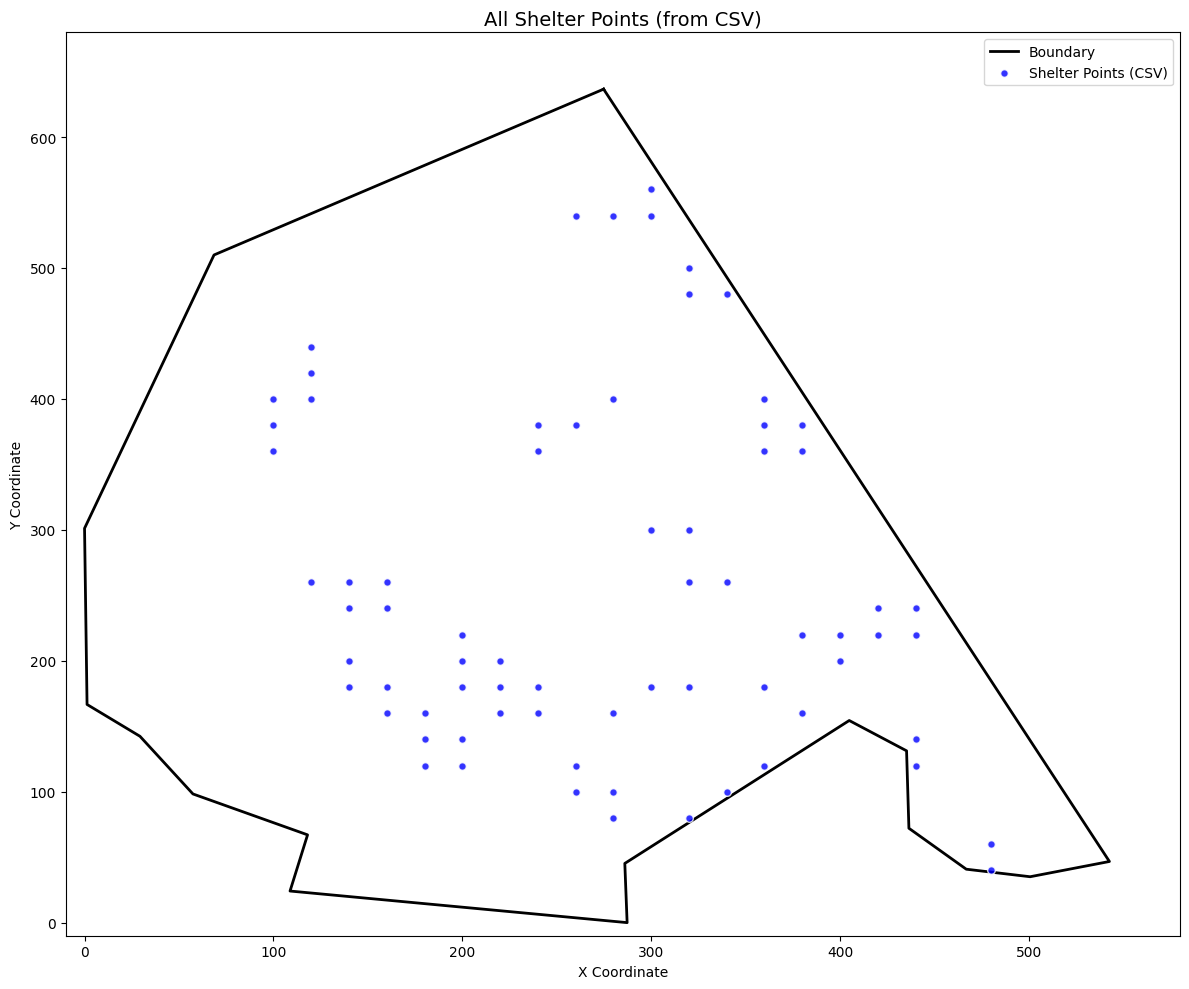

In [2]:
import pandas as pd
import json
import numpy as np
import matplotlib.pyplot as plt
import os

def plot_shelter_points_only(boundary_path, csv_path):
    # 1. 加载 CSV 坐标点
    shelter_df = pd.read_csv(csv_path)

    # 2. 绘图
    plt.figure(figsize=(12, 10), facecolor='white')
    ax = plt.gca()

    # 3. 叠加边界线
    if os.path.exists(boundary_path):
        with open(boundary_path, 'r', encoding='utf-8') as f:
            boundary_data = json.load(f)
            feature = boundary_data['features'][0]
            boundary_coords = np.array(feature['geometry']['coordinates'][0])
            plt.plot(
                boundary_coords[:, 0], boundary_coords[:, 1], 
                color='black', linewidth=2, label='Boundary', zorder=3
            )

    # 4. 只叠加 CSV 中的 71 个避难所坐标点
    plt.scatter(
        shelter_df['x'], 
        shelter_df['y'], 
        c='blue', 
        s=30, 
        marker='o', 
        edgecolors='white', 
        label='Shelter Points (CSV)', 
        zorder=4,
        alpha=0.8
    )

    # 5. 设置坐标范围与细节
    plt.xlim(-10, 580)
    plt.ylim(-10, 680)
    plt.title("All Shelter Points (from CSV)", fontsize=14)
    plt.xlabel("X Coordinate")
    plt.ylabel("Y Coordinate")

    plt.legend(loc='upper right')
    plt.grid(False)
    plt.tight_layout()
    plt.show()

# --- 执行 ---
base_path = r"D:\progamming\python_script\Social-physical-system-shelter"
boundary_file = os.path.join(base_path, "data_empirical", "boan.geojson")
csv_file = os.path.join(base_path, "data", "output", "shelter_points.csv")

plot_shelter_points_only(boundary_file, csv_file)

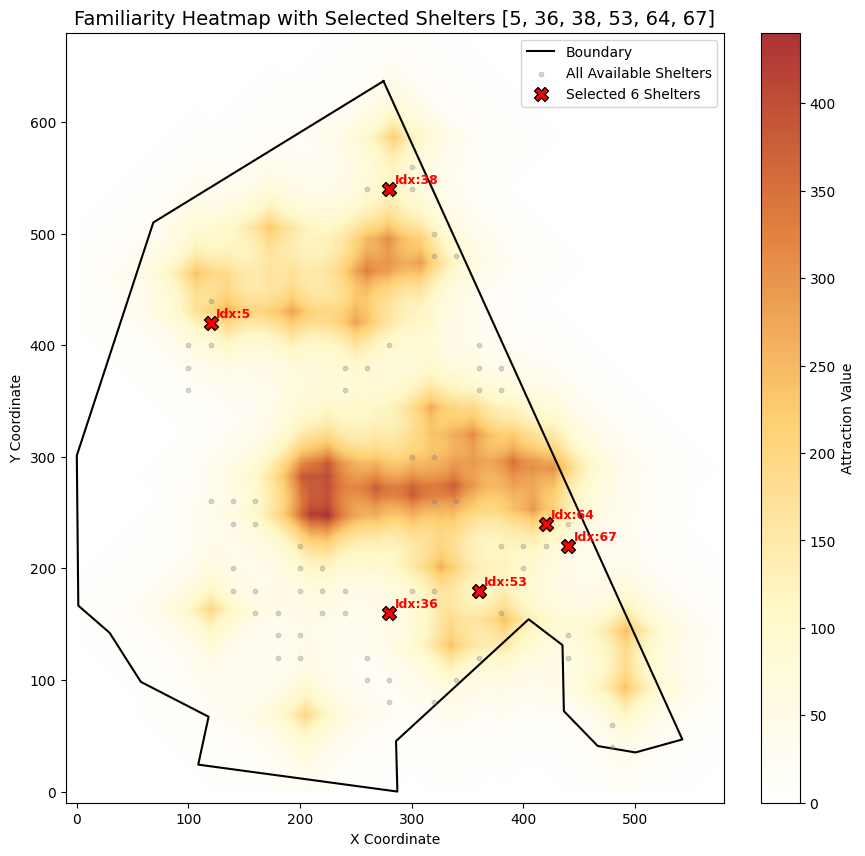

In [57]:
import pandas as pd
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import os

def plot_heatmap_with_selected_six(json_path, boundary_path, csv_path, selected_indices, grid_size=(700, 700)):
    # 1. 加载数据
    with open(json_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    flat_map = data.get("macro_environment", {}).get("map", [])
    matrix = np.array(flat_map).reshape(grid_size)
    matrix_plot = matrix.T.astype(float)
    
    shelter_df = pd.read_csv(csv_path)
    
    # 2. 筛选选中的 6 个点
    # 确保只选 6 个，并且索引在范围内
    selected_points = shelter_df[shelter_df['index'].isin(selected_indices)]

    # 3. 绘图配置
    colors = ["#ffffff", "#fff7bc", "#fec44f", "#d95f0e", "#990000"]
    custom_cmap = mcolors.LinearSegmentedColormap.from_list("smooth_heat", colors, N=256)

    plt.figure(figsize=(12, 10), facecolor='white')
    ax = plt.gca()

    # 4. 绘制背景热力图
    img = ax.imshow(
        matrix_plot, 
        extent=[0, grid_size[0], 0, grid_size[1]], 
        origin='lower', 
        cmap=custom_cmap, 
        vmin=0,           
        aspect='equal',
        interpolation='bilinear', 
        alpha=0.8,
        zorder=1
    )

    # 5. 绘制边界
    if os.path.exists(boundary_path):
        with open(boundary_path, 'r', encoding='utf-8') as f:
            boundary_data = json.load(f)
            feature = boundary_data['features'][0]
            boundary_coords = np.array(feature['geometry']['coordinates'][0])
            plt.plot(boundary_coords[:, 0], boundary_coords[:, 1], 
                     color='black', linewidth=1.5, label='Boundary', zorder=2)

    # 6. 绘制所有背景点（浅灰色，较小）
    plt.scatter(shelter_df['x'], shelter_df['y'], c='gray', s=10, alpha=0.3, label='All Available Shelters', zorder=3)

    # 7. 【重点】绘制选中的 6 个高亮解
    plt.scatter(
        selected_points['x'], 
        selected_points['y'], 
        c='red', 
        s=100, 
        marker='X', 
        edgecolors='black', 
        label='Selected 6 Shelters', 
        zorder=5
    )

    # 给这 6 个点加上索引标注
    for i, row in selected_points.iterrows():
        plt.text(row['x'] + 5, row['y'] + 5, f"Idx:{int(row['index'])}", 
                 fontsize=9, fontweight='bold', color='red', zorder=6)

    # 8. 细节打磨
    plt.xlim(-10, 580)
    plt.ylim(-10, 680)
    plt.title(f"Familiarity Heatmap with Selected Shelters {selected_indices}", fontsize=14)
    plt.xlabel("X Coordinate")
    plt.ylabel("Y Coordinate")
    plt.colorbar(img, fraction=0.046, pad=0.04, label='Attraction Value')
    plt.legend(loc='upper right')
    plt.grid(False)
    plt.show()

# --- 你只需要修改这里的 6 个索引 ---
# 示例：根据你之前 GA 日志里的 Top1 个体索引 [19, 22, 33, 52, 59, 64]
#my_six_indices = [6, 47, 52, 20, 62, 67]
#my_six_indices = [64, 29, 50, 45, 51, 52]
my_six_indices = [5, 36, 38, 53, 64, 67]


base_path = r"D:\progamming\python_script\Social-physical-system-shelter"
target_json = os.path.join(base_path, "data", "env_data", "attraction_matrix_familiar_points.json")
boundary_file = os.path.join(base_path, "data_empirical", "boan.geojson")
csv_file = os.path.join(base_path, "data", "output", "shelter_points.csv")

plot_heatmap_with_selected_six(target_json, boundary_file, csv_file, my_six_indices)


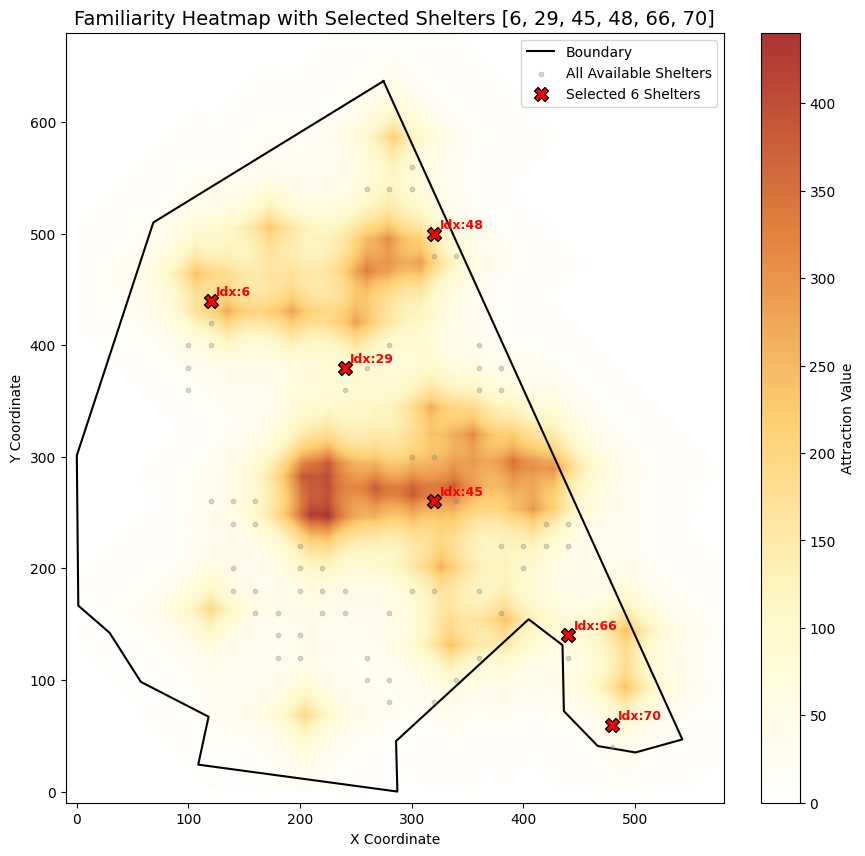

In [46]:
import pandas as pd
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import os

def plot_heatmap_with_selected_six(json_path, boundary_path, csv_path, selected_indices, grid_size=(700, 700)):
    # 1. 加载数据
    with open(json_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    flat_map = data.get("macro_environment", {}).get("map", [])
    matrix = np.array(flat_map).reshape(grid_size)
    matrix_plot = matrix.T.astype(float)
    
    shelter_df = pd.read_csv(csv_path)
    
    # 2. 筛选选中的 6 个点
    # 确保只选 6 个，并且索引在范围内
    selected_points = shelter_df[shelter_df['index'].isin(selected_indices)]

    # 3. 绘图配置
    colors = ["#ffffff", "#fff7bc", "#fec44f", "#d95f0e", "#990000"]
    custom_cmap = mcolors.LinearSegmentedColormap.from_list("smooth_heat", colors, N=256)

    plt.figure(figsize=(12, 10), facecolor='white')
    ax = plt.gca()

    # 4. 绘制背景热力图
    img = ax.imshow(
        matrix_plot, 
        extent=[0, grid_size[0], 0, grid_size[1]], 
        origin='lower', 
        cmap=custom_cmap, 
        vmin=0,           
        aspect='equal',
        interpolation='bilinear', 
        alpha=0.8,
        zorder=1
    )

    # 5. 绘制边界
    if os.path.exists(boundary_path):
        with open(boundary_path, 'r', encoding='utf-8') as f:
            boundary_data = json.load(f)
            feature = boundary_data['features'][0]
            boundary_coords = np.array(feature['geometry']['coordinates'][0])
            plt.plot(boundary_coords[:, 0], boundary_coords[:, 1], 
                     color='black', linewidth=1.5, label='Boundary', zorder=2)

    # 6. 绘制所有背景点（浅灰色，较小）
    plt.scatter(shelter_df['x'], shelter_df['y'], c='gray', s=10, alpha=0.3, label='All Available Shelters', zorder=3)

    # 7. 【重点】绘制选中的 6 个高亮解
    plt.scatter(
        selected_points['x'], 
        selected_points['y'], 
        c='red', 
        s=100, 
        marker='X', 
        edgecolors='black', 
        label='Selected 6 Shelters', 
        zorder=5
    )

    # 给这 6 个点加上索引标注
    for i, row in selected_points.iterrows():
        plt.text(row['x'] + 5, row['y'] + 5, f"Idx:{int(row['index'])}", 
                 fontsize=9, fontweight='bold', color='red', zorder=6)

    # 8. 细节打磨
    plt.xlim(-10, 580)
    plt.ylim(-10, 680)
    plt.title(f"Familiarity Heatmap with Selected Shelters {selected_indices}", fontsize=14)
    plt.xlabel("X Coordinate")
    plt.ylabel("Y Coordinate")
    plt.colorbar(img, fraction=0.046, pad=0.04, label='Attraction Value')
    plt.legend(loc='upper right')
    plt.grid(False)
    plt.show()

# --- 你只需要修改这里的 6 个索引 ---
# 示例：根据你之前 GA 日志里的 Top1 个体索引 [19, 22, 33, 52, 59, 64]
my_six_indices = [6, 29, 45, 48, 66, 70]

base_path = r"D:\progamming\python_script\Social-physical-system-shelter"
target_json = os.path.join(base_path, "data", "env_data", "attraction_matrix_familiar_points.json")
boundary_file = os.path.join(base_path, "data_empirical", "boan.geojson")
csv_file = os.path.join(base_path, "data", "output", "shelter_points.csv")

plot_heatmap_with_selected_six(target_json, boundary_file, csv_file, my_six_indices)

